# Text Classification and Generation Project

## Project Description

This project explores natural language processing techniques using TensorFlow and Keras, focusing on challenges faced by a **news portal**. The portal requires solutions for **classifying articles** based on their titles and descriptions, and for **assisting writers** in maintaining a consistent style by suggesting subsequent words.

## 1.1. Loading Texts

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


2025-10-27 18:41:36.912571: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 18:41:37.507886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 18:41:39.458316: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
url ='data_text/train.zip'

In [3]:
df = pd.read_csv(url, header=None, names=['ClassIndex','Título','Descrição'])
df.head()

,ClassIndex,Título,Descrição
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
df['Texto'] = df['Título'] + ' ' + df['Descrição']

In [5]:
df['Texto']

0         Wall St. Bears Claw Back Into the Black (Reute...
1         Carlyle Looks Toward Commercial Aerospace (Reu...
2         Oil and Economy Cloud Stocks' Outlook (Reuters...
3         Iraq Halts Oil Exports from Main Southern Pipe...
4         Oil prices soar to all-time record, posing new...
                                ...                        
119995    Pakistan's Musharraf Says Won't Quit as Army C...
119996    Renteria signing a top-shelf deal Red Sox gene...
119997    Saban not going to Dolphins yet The Miami Dolp...
119998    Today's NFL games PITTSBURGH at NY GIANTS Time...
119999    Nets get Carter from Raptors INDIANAPOLIS -- A...
Name: Texto, Length: 120000, dtype: object

In [6]:
df['ClassIndex'] = df['ClassIndex'] - 1

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df['Texto'].values, df['ClassIndex'].values, test_size=0.2, random_state=4266)

## 1.2. Encoding the Text

In [8]:
VOCAB_SIZE = 2500
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)

I0000 00:00:1761438045.749062  157817 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
encoder.adapt(X_train)

In [10]:
vocab = encoder.get_vocabulary()
vocab_python = [str(token) for token in vocab]
print(vocab_python[::10])

['', '39s', 'it', 'was', 'more', 'company', 'than', 'microsoft', 'prices', 'people', 'next', 'sales', 'state', 'most', 'profit', 'lead', 'online', '39t', 'red', 'during', 'say', 'between', 'country', 'mobile', 'quarter', 'being', 'dollar', 'stock', 'sox', 'olympic', 'users', 'price', 'how', 'peace', 'six', 'key', 'i', 'should', 'financial', 'leaders', 'house', 'sun', 'used', 'seven', 'israel', 'future', 'trial', 'half', 'customers', 'defense', 'arafat', 'northern', 'due', 'men', 'hopes', 'using', 'scored', 'university', 'texas', 'mark', 'we', 'accused', 'profits', '18', 'possible', 'call', 'rally', 'teams', 'division', '7', 'takeover', 'production', 'outlook', 'began', 'helped', 'opening', 'sept', 'spain', 'hours', 'starting', 'nine', 'pressure', 'executives', 'personal', 'once', 'italian', 'push', 'continued', 'rising', 'kill', 'powerful', 'side', 'designed', 'groups', 'mission', 'najaf', 'fired', 'sold', 'launches', 'guard', 'sent', 'goes', 'does', 'captain', 'golf', 'strip', 'irelan

## 1.3. Creating a Model

In [11]:
# Creating the model
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=16,
        mask_zero=True),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [12]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
X_test[1]

'Time magazines #39; report on J amp;K draws ire Officials in New Delhi are cross about a Time magazine story that says that Prime Minister Manmohan Singh will offer territorial concessions on Kashmir to Pakistan President Pervez Musharraf when they meet in New York Friday.'

In [14]:
y_test[1]

np.int64(0)

In [15]:
X_test.shape

(24000,)

In [16]:
model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.25102782, 0.24719635, 0.24903342, 0.25274238]], dtype=float32)

In [17]:
model.predict(X_test[:1]).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([3])

# 2. Classifying the Text

## 2.1. Training with Dense Layers

In [18]:
epochs = 10
history = model.fit(
    X_train, 
    y_train, 
    epochs=epochs, 
    validation_data=(X_test, y_test)
    )

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.6784 - loss: 1.1309 - val_accuracy: 0.7619 - val_loss: 0.7973
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.8092 - loss: 0.6483 - val_accuracy: 0.8244 - val_loss: 0.5586
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8445 - loss: 0.4978 - val_accuracy: 0.8527 - val_loss: 0.4570
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.8656 - loss: 0.4165 - val_accuracy: 0.8699 - val_loss: 0.3991
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.8784 - loss: 0.3705 - val_accuracy: 0.8783 - val_loss: 0.3680
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8871 - loss: 0.3439 - val_accuracy: 0.8833 - val_loss: 0.3507
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.8917 - loss: 0.3272 - val_accuracy: 0.8875 - val_loss: 0.3389
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.8952 - loss: 0

In [19]:
def plot_results(history,epochs):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epoch_interval = range(epochs)
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.plot(epoch_interval, acc, label='Training Accuracy')
  plt.plot(epoch_interval, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')


  plt.subplot(1, 2, 2)
  plt.plot(epoch_interval, loss, label='Training Loss')
  plt.plot(epoch_interval, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.show()

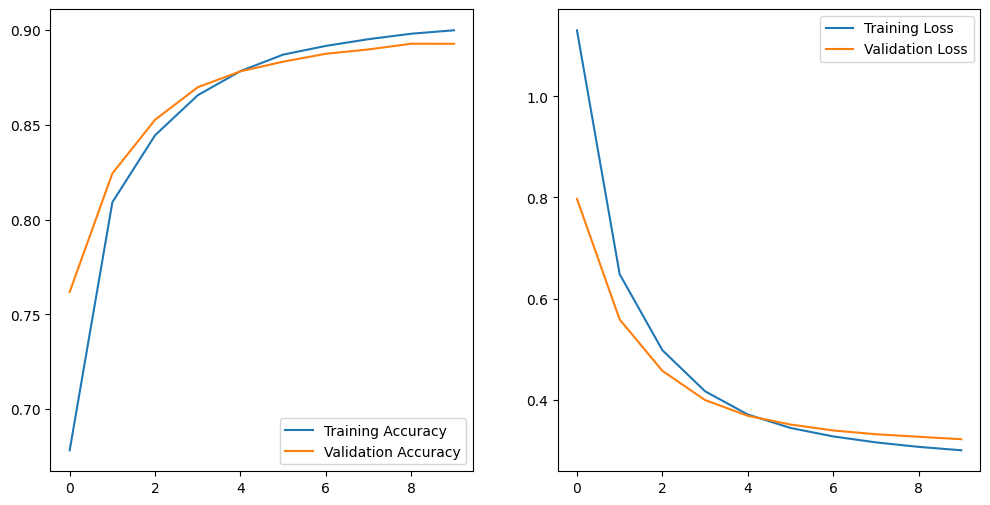

In [20]:
plot_results(history,epochs)

## 2.2. Adding Convolutional Layers

In [21]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=16,
        mask_zero=True
    ),
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'), # convolutional layer
    tf.keras.layers.MaxPooling1D(),
    tf.keras.layers.Conv1D(128, kernel_size=4, activation='relu'), # convolutional layer
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])


In [22]:
# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
epochs = 10
history = model.fit(
    X_train, 
    y_train, 
    epochs=epochs, 
    validation_data=(X_test, y_test)
    )

Epoch 1/10


/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
2025-10-25 21:24:56.127500: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.6643 - loss: 0.7897 - val_accuracy: 0.8550 - val_loss: 0.4302
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.8587 - loss: 0.4278 - val_accuracy: 0.8697 - val_loss: 0.3919
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8737 - loss: 0.3897 - val_accuracy: 0.8754 - val_loss: 0.3761
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.8796 - loss: 0.3707 - val_accuracy: 0.8763 - val_loss: 0.3755
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8823 - loss: 0.3574 - val_accuracy: 0.8800 - val_loss: 0.3617
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.8847 - loss: 0.3484 - val_accuracy: 0.8820 - val_loss: 0.3534
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 39s 13ms/step - accuracy: 0.8869 - loss: 0.3390 - val_accuracy: 0.8831 - val_loss: 0.3495
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - accuracy: 0.8894 - loss: 0.33

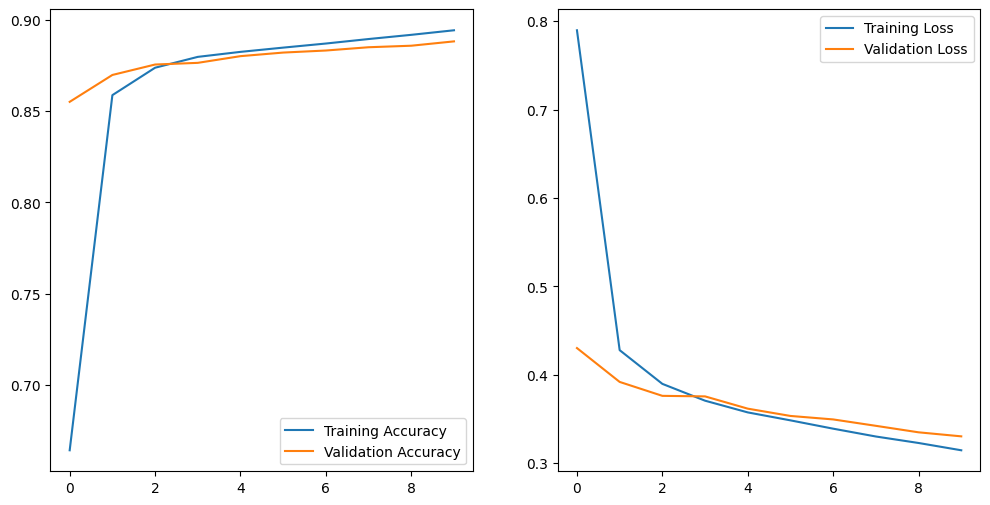

In [24]:
plot_results(history,epochs)

## 2.3. Adding LSTM Layers

In [25]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),  
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [26]:
# Compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )

In [27]:
epochs = 20
history = model.fit(
    X_train, 
    y_train, 
    epochs=epochs, 
    validation_data=(X_test, y_test)
    )

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 112s 37ms/step - accuracy: 0.7970 - loss: 0.5628 - val_accuracy: 0.8746 - val_loss: 0.3689
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 107s 36ms/step - accuracy: 0.8873 - loss: 0.3514 - val_accuracy: 0.8878 - val_loss: 0.3313
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 105s 35ms/step - accuracy: 0.8966 - loss: 0.3218 - val_accuracy: 0.8927 - val_loss: 0.3181
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 107s 35ms/step - accuracy: 0.9010 - loss: 0.3043 - val_accuracy: 0.8954 - val_loss: 0.3093
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 105s 35ms/step - accuracy: 0.9054 - loss: 0.2917 - val_accuracy: 0.8947 - val_loss: 0.3129
Epoch 6/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 103s 34ms/step - accuracy: 0.9084 - loss: 0.2813 - val_accuracy: 0.8932 - val_loss: 0.3165
Epoch 7/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 107s 36ms/step - accuracy: 0.9108 - loss: 0.2738 - val_accuracy: 0.8889 - val_loss: 0.3242
Epoch 8/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 99s 33ms/step - accuracy: 0

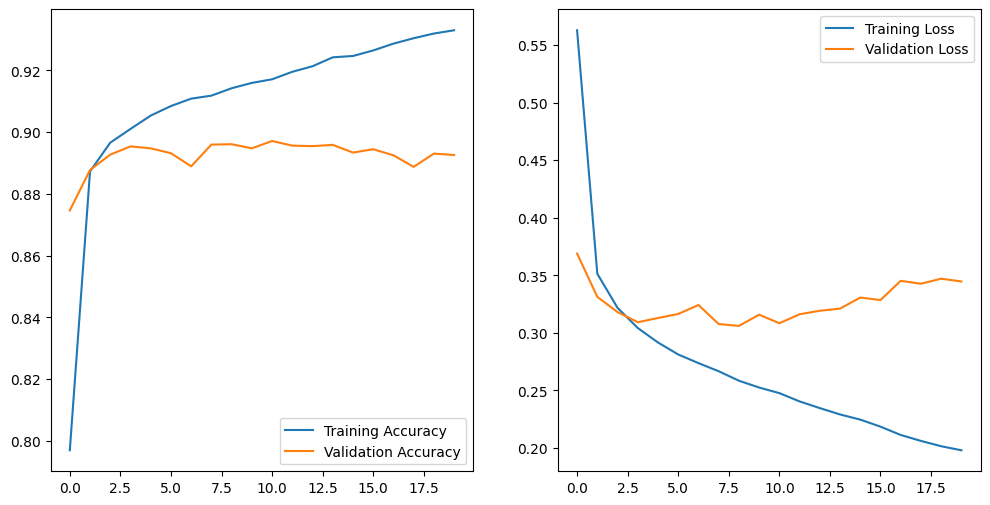

In [28]:
plot_results(history,epochs)

In [29]:
model.predict(X_test[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[9.9957675e-01, 3.1830918e-06, 2.4636518e-04, 1.7372530e-04]],
      dtype=float32)

In [30]:
model.predict(X_test[1:2]).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([0])

In [31]:
y_test[1]

np.int64(0)

# 3. Validating the Results

## 3.1. Hyperparameters - Searching for the Best Parameters

In [32]:
# Function to create the model
def build_model(hp):
    model = tf.keras.Sequential([
        encoder,
        tf.keras.layers.Embedding(
            input_dim=len(encoder.get_vocabulary()),
            output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
            mask_zero=True
        ),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
            units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
            return_sequences=True
        )),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
            units=hp.Int('lstm_units', min_value=16, max_value=64, step=16)
        )),
        tf.keras.layers.Dense(
            units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
            activation='relu'
        ),
        tf.keras.layers.Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [33]:
# Tuner configuration for hyperparameter optimization
max_epochs = 5
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=max_epochs,
    factor=3,
    directory='my_dir',
    project_name='classification_optimization'
)

Reloading Tuner from my_dir/classification_optimization/tuner0.json


## 3.2. Applying Cross-validation

In [34]:
# Function to perform cross-validation and hyperparameter optimization
def run_tuner(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, val_index in kf.split(X):
        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]

        tuner.search(X_train_fold, y_train_fold, epochs=10, validation_data=(X_val_fold, y_val_fold))

    # Summary of the best hyperparameters found
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"""
          Hyperparameter tuning is complete. The optimal embedding dimensions is {best_hps.get('embedding_dim')}, the optimal LSTM units is {best_hps.get('lstm_units')}, and the optimal dense units is {best_hps.get('dense_units')}, and the optimal dropout rate is {best_hps.get('dropout')}.
    """)

    return best_hps

In [35]:
best_hps = run_tuner(X_train, y_train)


          Hyperparameter tuning is complete. The optimal embedding dimensions is 128, the optimal LSTM units is 96, and the optimal dense units is 32, and the optimal dropout rate is 0.4.
    


## 3.3. Testing the Network

In [36]:
# Creating the final model using the best hyperparameters
final_model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=best_hps.get('embedding_dim'),
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        units=best_hps.get('lstm_units'),
        return_sequences=True
    )),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
        units=best_hps.get('lstm_units') // 2
    )),
    tf.keras.layers.Dense(
        units=best_hps.get('dense_units'),
        activation='relu'
    ),
    tf.keras.layers.Dropout(rate=best_hps.get('dropout')),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [37]:
# Compiling the final model
final_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [38]:
# Training the final model with all the training data
epochs = 10
history = final_model.fit(
    X_train, 
    y_train, 
    epochs=epochs, 
    validation_data=(X_test, y_test)
    )

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 107s 35ms/step - accuracy: 0.8623 - loss: 0.4169 - val_accuracy: 0.8846 - val_loss: 0.3302
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 104s 35ms/step - accuracy: 0.8933 - loss: 0.3224 - val_accuracy: 0.8963 - val_loss: 0.3051
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 103s 34ms/step - accuracy: 0.9036 - loss: 0.2856 - val_accuracy: 0.8942 - val_loss: 0.3006
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 102s 34ms/step - accuracy: 0.9130 - loss: 0.2523 - val_accuracy: 0.8999 - val_loss: 0.3031
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 103s 34ms/step - accuracy: 0.9237 - loss: 0.2221 - val_accuracy: 0.8970 - val_loss: 0.3111
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 108s 36ms/step - accuracy: 0.9318 - loss: 0.1942 - val_accuracy: 0.8980 - val_loss: 0.3273
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 103s 34ms/step - accuracy: 0.9419 - loss: 0.1647 - val_accuracy: 0.8933 - val_loss: 0.3677
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 105s 35ms/step - accuracy: 

In [39]:
# Making predictions on the test set
y_pred = final_model.predict(X_test)
y_pred_class = y_pred.argmax(axis=1)

750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


In [40]:
# Generating the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

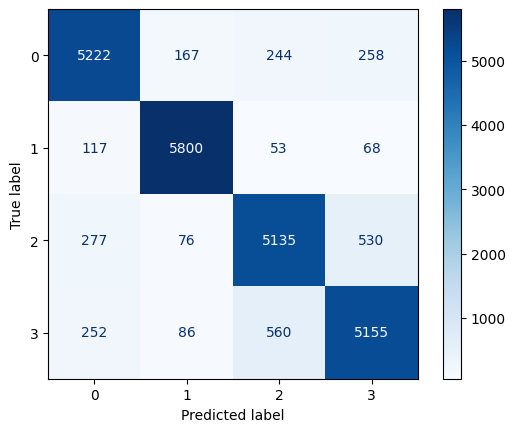

In [41]:
# Displaying the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0, 1, 2, 3])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# 4. Generating Texts

  4.1. Organizing the Data

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random

In [3]:
# Clearing the TensorFlow session
tf.keras.backend.clear_session()

In [4]:
#Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [5]:
#Loading and preparing data
url ='data_text/train.zip'
df = pd.read_csv(url, header=None, names=['ClassIndex','Título','Descrição'])
df['Texto'] = df['Título'] + ' ' + df['Descrição']

In [6]:
df['Texto']

0         Wall St. Bears Claw Back Into the Black (Reute...
1         Carlyle Looks Toward Commercial Aerospace (Reu...
2         Oil and Economy Cloud Stocks' Outlook (Reuters...
3         Iraq Halts Oil Exports from Main Southern Pipe...
4         Oil prices soar to all-time record, posing new...
                                ...                        
119995    Pakistan's Musharraf Says Won't Quit as Army C...
119996    Renteria signing a top-shelf deal Red Sox gene...
119997    Saban not going to Dolphins yet The Miami Dolp...
119998    Today's NFL games PITTSBURGH at NY GIANTS Time...
119999    Nets get Carter from Raptors INDIANAPOLIS -- A...
Name: Texto, Length: 120000, dtype: object

In [7]:
# Sample of 10000 texts
df_sample = df.sample(n=10000, random_state=42)
corpus = df_sample['Texto'].tolist()

In [8]:
# Vectorization
max_vocab_size = 2000
max_sequence_len = 50

vectorizer = TextVectorization(
    max_tokens=max_vocab_size,
    output_sequence_length=max_sequence_len,
    output_mode='int'
)
vectorizer.adapt(corpus)

I0000 00:00:1761601355.307941   59972 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
# Saving the vectorization layer
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

In [10]:
# Tokenizing the corpus
tokenized_corpus = vectorizer(corpus)

In [11]:
# Creating n-gram sequences
input_sequences = []
for token_list in tokenized_corpus.numpy():
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total sequences generated: {len(input_sequences)}")

Total sequences generated: 490000


In [12]:
# Preparing sequences
def prepare_sequences(sequences):
    # Remove trailing zeros from each sequence
    sequences_without_trailing_zeros = []
    for seq in sequences:
        last_nonzero_index = np.argmax(seq[::-1] != 0)
        if last_nonzero_index == 0 and seq[-1] == 0:
            sequences_without_trailing_zeros.append(np.array([0])) 
        else:
            sequences_without_trailing_zeros.append(seq[:-last_nonzero_index or None]) 

    # Remove duplicate sequences
    unique_sequences = []
    for seq in sequences_without_trailing_zeros:
        if seq.tolist() not in unique_sequences:  # Check if the sequence is already in the list
            unique_sequences.append(seq.tolist())  # Add to the list if it's unique

    # Find the maximum length of the sequences without trailing zeros
    max_sequence_len = max(len(seq) for seq in unique_sequences)

    # Add padding to the left to ensure the same length
    padded_sequences = pad_sequences(unique_sequences, maxlen=max_sequence_len, padding='post', truncating='post')

    return padded_sequences

In [13]:
# Preparing sequences
input_sequences_prepared = prepare_sequences(input_sequences)
print(f"Prepared sequences shape: {input_sequences_prepared.shape}")

Prepared sequences shape: (346086, 50)


In [14]:
# Separating the features (inputs) and the label (output)
X = input_sequences_prepared[:, :-1]
y = input_sequences_prepared[:, -1]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (346086, 49)
Shape y: (346086,)


In [15]:
# Shape of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X size (MB):", X.nbytes / 1024 / 1024)
print("y size (MB):", y.nbytes / 1024 / 1024)

X shape: (346086, 49)
y shape: (346086,)
X size (MB): 64.6904525756836
y size (MB): 1.3202133178710938


## 4.2. Creating and Training the Model

In [16]:
# Setting up the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [17]:
# Defining the model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=max_vocab_size,
        output_dim=128,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(max_vocab_size, activation='softmax')  
])


model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=[
        'accuracy',  # sparse categorical accuracy
        tf.keras.metrics.sparse_top_k_categorical_accuracy   # compatible with sparse labels
    ]
)

### Benefits of this approach

**EarlyStopping** – stops early if there’s no improvement, saving time.

**ModelCheckpoint** – ensures you have the best model saved even if training continues.

**ReduceLROnPlateau** – automatically reduces the learning rate if the model plateaus, helping improve convergence and avoid “loss oscillation.”



In [18]:
# Optimized callbacks

# EarlyStopping (same as yours)
early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_loss' if you have validation
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    'best_model.keras',   
    monitor='val_loss',    
    save_best_only=True,
    verbose=1
)

# Reduce learning rate if the model stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   
    factor=0.5,       # reduces to 50% of the current value
    patience=3,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
# Training the model
epochs=10
history = model.fit(
    X,
    y,
    epochs=epochs,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10


2025-10-27 18:58:08.934913: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


5408/5408 ━━━━━━━━━━━━━━━━━━━━ 201s 36ms/step - accuracy: 0.9852 - loss: 0.3755 - sparse_top_k_categorical_accuracy: 0.9873 - learning_rate: 5.0000e-04
Epoch 2/10


/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,sparse_top_k_categorical_accuracy
  current = self.get_monitor_value(logs)
/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/home/anderjcruz/Deep-Learning/venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,sparse_top_k_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


5408/5408 ━━━━━━━━━━━━━━━━━━━━ 192s 35ms/step - accuracy: 0.9978 - loss: 0.0246 - sparse_top_k_categorical_accuracy: 0.9986 - learning_rate: 5.0000e-04
Epoch 3/10
5408/5408 ━━━━━━━━━━━━━━━━━━━━ 194s 36ms/step - accuracy: 0.9977 - loss: 0.0209 - sparse_top_k_categorical_accuracy: 0.9986 - learning_rate: 5.0000e-04
Epoch 4/10
5408/5408 ━━━━━━━━━━━━━━━━━━━━ 205s 38ms/step - accuracy: 0.9977 - loss: 0.0192 - sparse_top_k_categorical_accuracy: 0.9986 - learning_rate: 5.0000e-04
Epoch 5/10
4997/5408 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9975 - loss: 0.0258 - sparse_top_k_categorical_accuracy: 0.9984

In [ ]:
# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 49, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 49, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2000)           │       130,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,465,842 (9.41 MB)

 Trainable params: 821,904 (3.14 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 1,643,810 (6.27 MB)

## 4.3. Predicting the Next Word

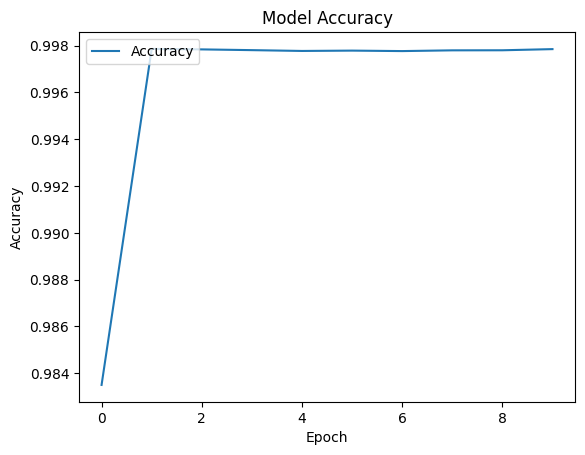

In [ ]:
# Plot accuracy and loss during training
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy'], loc='upper left')
plt.show()

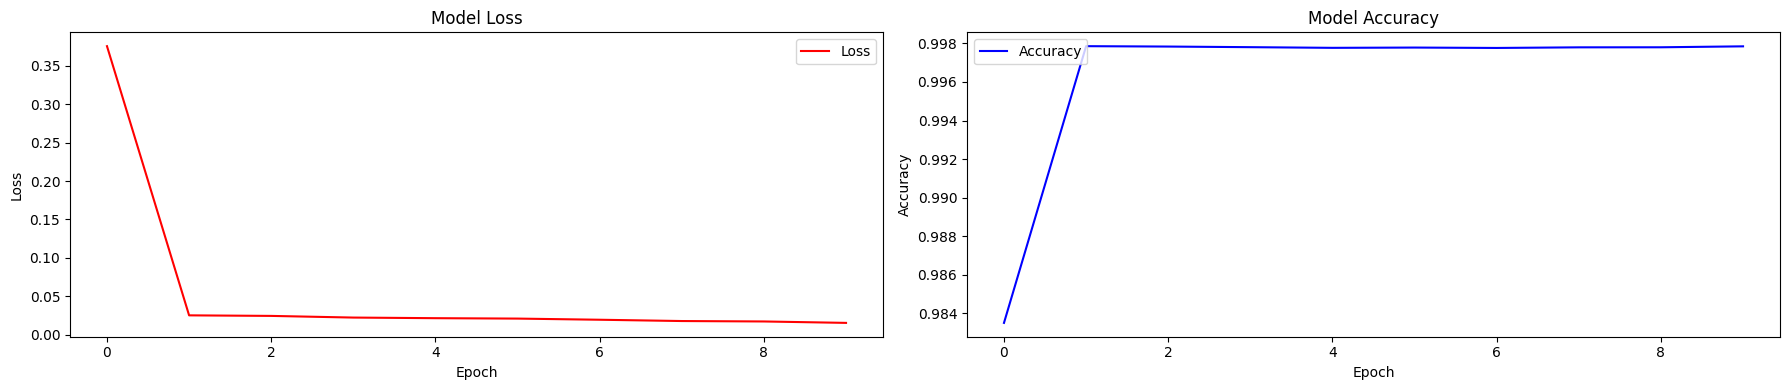

In [ ]:
# Create 1 row and 3 columns of subplots
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

# Plot Loss
axs[0].plot(history.history['loss'], label='Loss', color='red')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend(loc='upper right')

# Plot Accuracy
axs[1].plot(history.history['accuracy'], label='Accuracy', color='blue')
axs[1].set_title('Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend(loc='upper left')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [ ]:
# Predicting the next words

def predict_next_words(model, vectorizer, text, max_sequence_len, top_k=3):
    import numpy as np
    from tensorflow.keras.preprocessing.sequence import pad_sequences

    # Vectorize the input text
    tokenized_text = vectorizer([text])
    tokenized_text = np.squeeze(tokenized_text)  # Remove extra dimension

    # Left-padding ('pre') for compatibility with cuDNN
    padded_text = pad_sequences([tokenized_text], maxlen=max_sequence_len, padding='pre')

    # Predict probabilities for each token in the vocabulary
    predicted_probs = model.predict(padded_text, verbose=0)[0]

    # Select the top_k indices with the highest probability
    top_k_indices = np.argsort(predicted_probs)[-top_k:][::-1]

    # Convert indices back to words
    predicted_words = [vectorizer.get_vocabulary()[index] for index in top_k_indices]

    return predicted_words



In [ ]:
# Test predictions
test_texts = [
    "The FBI is warning consumers against using public phone charging stations in order to",
    "Apple needs to make the iPhone more appealing to younger consumers.",
    "Making measures for a sustainable future An analyzing tool from Sandvik Coromant helps customers reduce their energy consumption and carbon emissions based on data."
]

# Generate predictions for each text
for i, text in enumerate(test_texts, 1):
    predicted_words = predict_next_words(model, vectorizer, text, max_sequence_len=50, top_k=3)
    print(f"Prediction {i}: {predicted_words}")

Prediction 1: ['', '[UNK]', np.str_('said')]
Prediction 2: ['', np.str_('said'), np.str_('from')]
Prediction 3: ['', '[UNK]', np.str_('the')]


In [ ]:
model.save("seer_model.keras", save_format="keras")